In [2]:
import os
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
from langchain_groq import ChatGroq
model=ChatGroq(model="openai/gpt-oss-120b")


c:\agentic ai\llm\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [3]:
from langchain_community.tools import DuckDuckGoSearchRun
search1=DuckDuckGoSearchRun()

In [4]:
from langchain_experimental.tools import PythonREPLTool

python_tool=PythonREPLTool()

In [5]:
from langchain_community.tools import YahooFinanceNewsTool

finance = YahooFinanceNewsTool()

In [6]:
tools=[search1,python_tool,finance]
llm_with_tools=model.bind_tools(tools,parallel_tool_calls=False)

In [7]:
from typing import Annotated,TypedDict
from langgraph.graph import StateGraph,START,END
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages

class MessagesState(TypedDict):
    messages:Annotated[list[AnyMessage],add_messages]

In [10]:
from langchain_core.messages import SystemMessage,HumanMessage

sys_msg = SystemMessage(content="""
You are an AI agent with access to tools: Search, Finance, and Python.

- Use Search for general or external info
- Use Finance for stock/market data
- Use Python for calculations or data processing
- Always use tools when accuracy is needed
- Do not guess if a tool can help
- Return only the final answer (no reasoning)
""")

def assistant(state:MessagesState):
   return {"messages":[llm_with_tools.invoke([sys_msg]+state["messages"])]}

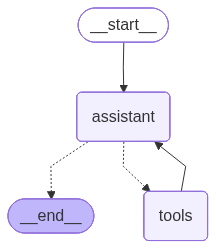

In [11]:
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import tools_condition
from langgraph.prebuilt import ToolNode
from IPython.display import Image,display

builder=StateGraph(MessagesState)

#Define the node
builder.add_node("assistant",assistant)
builder.add_node("tools",ToolNode(tools))

#define the edges

builder.add_edge(START,"assistant")
builder.add_conditional_edges("assistant",
                              tools_condition)
builder.add_edge("tools","assistant")


react_graph=builder.compile()

display(Image(react_graph.get_graph().draw_mermaid_png()))

In [12]:
messages=HumanMessage(content="can you define the meaning of ReAct in llm and also its purpose?")
messages=react_graph.invoke({"messages":messages})
messages

{'messages': [HumanMessage(content='can you define the meaning of ReAct in llm and also its purpose?', additional_kwargs={}, response_metadata={}, id='cd5e561a-ac63-4495-800b-116ccc6175ec'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks: "can you define the meaning of ReAct in llm and also its purpose?" Need to define ReAct (Reasoning and Acting) in large language models, its purpose. Likely no need for external sources, but could verify. Use search to get definition.', 'tool_calls': [{'id': 'fc_8922194c-7b55-4c95-b4af-75ee33e2a19d', 'function': {'arguments': '{"query":"ReAct prompting LLM meaning purpose"}', 'name': 'duckduckgo_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 95, 'prompt_tokens': 354, 'total_tokens': 449, 'completion_time': 0.202280982, 'completion_tokens_details': {'reasoning_tokens': 59}, 'prompt_time': 0.019914453, 'prompt_tokens_details': None, 'queue_time': 0.051833386, 'total_time': 0.22219

In [13]:
for i in messages["messages"]:
    i.pretty_print()

================================ Human Message =================================

can you define the meaning of ReAct in llm and also its purpose?
================================== Ai Message ==================================
Tool Calls:
  duckduckgo_search (fc_8922194c-7b55-4c95-b4af-75ee33e2a19d)
 Call ID: fc_8922194c-7b55-4c95-b4af-75ee33e2a19d
  Args:
    query: ReAct prompting LLM meaning purpose
================================= Tool Message =================================
Name: duckduckgo_search

By prompting the LLM to alternate between thinking and acting, ReAct transforms it into an active agent in its environment, capable of solving tasks ... The natural interface to LLMs, a string of text called a prompt, has been a key component of its success. ... by the LLM deployer (as a system prompt ... AutoGen supports different LLM prompting and reasoning strategies, such as ReAct, Reflection/Self-Critique, and more. The React frontend collects LLM input and displays output, not